# Capitolo 2 — Lo stesso neurone, per prevedere un numero (§ 2.6)
Un neurone lineare in NumPy sul dataset *diabetes* di scikit-learn: divisione, normalizzazione, discesa del gradiente, confronto con la linea di base.

In [1]:
import sys; sys.path.insert(0, "..")
from utils import fissa_seme
import dati
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
fissa_seme(42)

## I dati e la divisione training / test

In [2]:
dati_d = load_diabetes()
X, y = dati_d.data, dati_d.target          # X: (442, 10)   y: (442,)
print(X.shape, y.shape, dati_d.feature_names)

idx = np.random.permutation(len(X))
X_tr, X_te = X[idx[:350]], X[idx[350:]]
y_tr, y_te = y[idx[:350]], y[idx[350:]]

(442, 10) (442,) ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## Normalizzazione con le statistiche del solo training

In [3]:
media_x, dev_x = X_tr.mean(axis=0), X_tr.std(axis=0)
media_y, dev_y = y_tr.mean(), y_tr.std()
Xn_tr = (X_tr - media_x) / dev_x
Xn_te = (X_te - media_x) / dev_x
yn_tr = (y_tr - media_y) / dev_y

## Il neurone lineare e la discesa del gradiente

In [4]:
w = np.zeros(10)
b = 0.0
storia = []
for epoca in range(500):
    y_hat = Xn_tr @ w + b
    storia.append(np.mean((y_hat - yn_tr) ** 2))
    delta = 2 * (y_hat - yn_tr) / len(yn_tr)
    w -= 0.05 * (Xn_tr.T @ delta)
    b -= 0.05 * delta.sum()

previsti = (Xn_te @ w + b) * dev_y + media_y      # torna alla scala originale
mae = np.mean(np.abs(previsti - y_te))
mae_media = np.mean(np.abs(y_tr.mean() - y_te))
print(f"MAE del neurone: {mae:.1f}    MAE rispondendo sempre la media: {mae_media:.1f}")

MAE del neurone: 49.3    MAE rispondendo sempre la media: 65.1


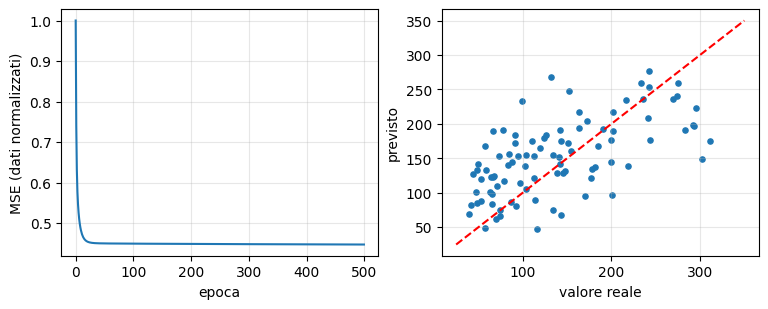

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(storia); ax[0].set_xlabel("epoca"); ax[0].set_ylabel("MSE (dati normalizzati)"); ax[0].grid(alpha=0.3)
ax[1].scatter(y_te, previsti, s=14); ax[1].plot([25, 350], [25, 350], "--", color="red"); ax[1].set_xlabel("valore reale"); ax[1].set_ylabel("previsto"); ax[1].grid(alpha=0.3)
plt.show()

## I pesi si leggono

In [6]:
for nome, peso in sorted(zip(dati_d.feature_names, w), key=lambda t: -abs(t[1])):
    print(f"{nome:5s} {peso:+.3f}")

s5    +0.404
bmi   +0.316
s1    -0.208
bp    +0.169
sex   -0.154
s3    -0.086
s2    +0.065
s4    +0.062
s6    +0.051
age   +0.011
